# ✈️ NASA C-MAPSS FD001 — 딥러닝: LSTM

| 항목 | 내용 |
|------|------|
| 데이터셋 | **FD001** — HPC 열화 (단일 조건) |
| 모델 | **LSTM** |
| 옵티마이저 | **AdamW** (weight_decay=Optuna 탐색) |
| LR Scheduler | **ReduceLROnPlateau** |
| Zero-padding 마스킹 | **✅ 적용** |
| N_TRIALS | **30** |

> **전 데이터셋 동일 실험 조건:** FD001~FD004 모두 AdamW + ReduceLROnPlateau 적용  
> 실행 전 반드시 **런타임 → 세션 재시작** 후 전체 실행하세요.


## 0. 환경 초기화 — 반드시 첫 번째 셀로 실행

In [2]:
# ⚠️ 독립 실험 보장: GPU 메모리 및 전역 상태 초기화
import gc, torch, numpy as np, random

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# 완전한 재현성 보장
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print('✅ 환경 초기화 완료')
print(f'   모델     : LSTM')
print(f'   데이터셋 : FD001')
print(f'   CUDA 사용: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


✅ 환경 초기화 완료
   모델     : LSTM
   데이터셋 : FD001
   CUDA 사용: True
   GPU: Tesla T4
   VRAM: 15.6 GB


## 1. 라이브러리 설치 및 임포트

In [3]:
import sys, subprocess
REQUIRED = ['torch','numpy','pandas','scikit-learn','matplotlib',
            'seaborn','optuna','mlflow','joblib','scipy']
for pkg in REQUIRED:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('✅ 설치 완료')


✅ 설치 완료


In [4]:
import os, warnings, time, json, math, platform
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, optuna, mlflow, mlflow.pytorch
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import logging
import matplotlib.font_manager as fm

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = r"C:\Windows\Fonts\malgun.ttf"
        font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"
        font_name = "AppleGothic"
    else:  # Colab / Linux
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq")
            os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

BG,BG2,GRID='#0f1117','#1a1d2e','#2d3148'
WHITE,GRAY='#ffffff','#aaaaaa'
C=['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
MODEL_COLOR = '#00d4ff'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG2,'axes.edgecolor':GRID,
    'axes.labelcolor':GRAY,'xtick.color':GRAY,'ytick.color':GRAY,'text.color':WHITE,
    'grid.color':GRID,'grid.alpha':0.4,'axes.grid':True,'font.size':10,
    'legend.facecolor':BG2,'legend.edgecolor':GRID})
force_korean_font()

# ── 전역 상수 ───────────────────────────────────────────────
DATA_DIR        = 'preprocessed'
DL_DIR          = 'preprocessed/dl'
RESULT_DIR      = 'results_dl_fd001_lstm'
MODEL_DIR       = 'models_dl_fd001_lstm'
MLFLOW_DIR      = 'mlruns'
EXPERIMENT_NAME = 'CMAPSS_FD001_DL_LSTM'
DATASET_NAME    = 'FD001'
MODEL_NAME_STR  = 'LSTM'

RANDOM_STATE  = 42
WINDOW_SIZE   = 30
CLIP_LOWER    = 0.0
BATCH_SIZE    = 256
N_TRIALS      = 30
EPOCHS_SEARCH = 50
EPOCHS_FINAL  = 100
PATIENCE      = 10
USE_ADAMW     = True
OPTIMIZER_NAME= 'AdamW'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print('✅ 설정 완료')
print(f'   Dataset={DATASET_NAME}  Model={MODEL_NAME_STR}')
print(f'   Device={DEVICE}  Optimizer={OPTIMIZER_NAME}')
print(f'   N_TRIALS={N_TRIALS}  EPOCHS_FINAL={EPOCHS_FINAL}')


✅ 한글 폰트 적용: NanumGothic
✅ 한글 폰트 적용: NanumGothic
✅ 설정 완료
   Dataset=FD001  Model=LSTM
   Device=cuda  Optimizer=AdamW
   N_TRIALS=30  EPOCHS_FINAL=100


## 2. 데이터 로드

=== 2. 데이터 로드 ===
DL 피처 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
X_sub:(14241, 30, 14)  X_val:(3490, 30, 14)  X_test:(100, 30, 14)
✅ val_eval 로드: preprocessed/dl/FD001_dl_val_eval_long.csv
val_eval: (20, 30, 14)  RUL: 29~112


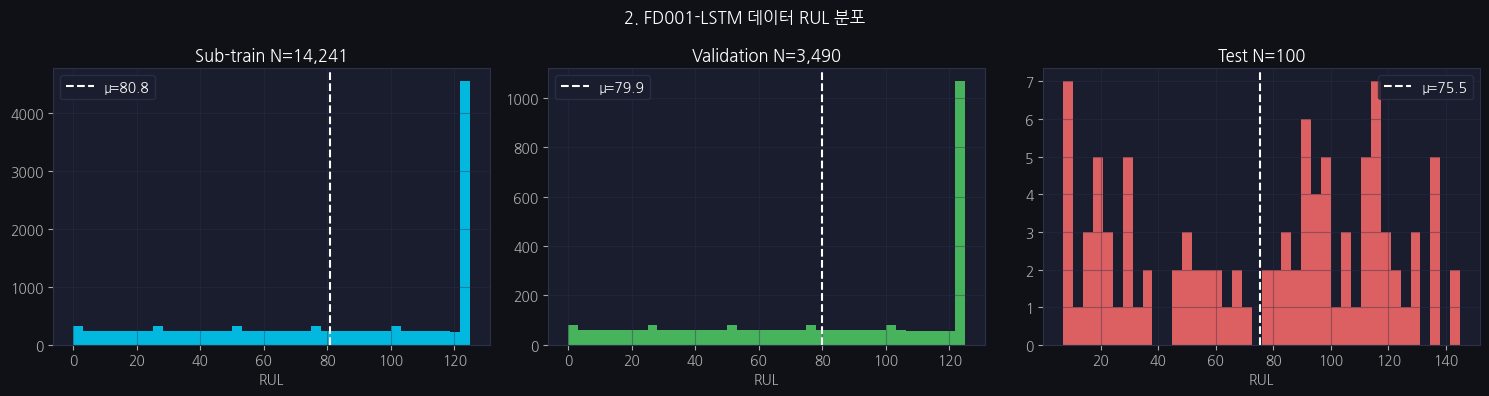

✅ 데이터 로드 완료


In [5]:
print('=== 2. 데이터 로드 ===')

dl_feat_path = os.path.join(DATA_DIR, 'FD001_dl_features.txt')
with open(dl_feat_path, 'r', encoding='utf-8') as f:
    DL_FEATURES = [l.strip() for l in f if l.strip()]
N_FEATURES = len(DL_FEATURES)
print(f'DL 피처 ({N_FEATURES}개): {DL_FEATURES}')

def load_long_format(path, feature_cols):
    df = pd.read_csv(path)
    df = df.sort_values(['sample_id','timestep']).reset_index(drop=True)
    n_samples   = df['sample_id'].nunique()
    window_size = int(df['timestep'].max()) + 1
    X = df[feature_cols].values.reshape(n_samples, window_size, len(feature_cols)).astype(np.float32)
    y = df.groupby('sample_id', sort=False)['RUL'].last().values.astype(np.float32)
    return X, y

X_sub,  y_sub  = load_long_format(os.path.join(DL_DIR,'FD001_dl_subtrain_long.csv'), DL_FEATURES)
X_val,  y_val  = load_long_format(os.path.join(DL_DIR,'FD001_dl_valid_long.csv'),    DL_FEATURES)
X_test, y_test = load_long_format(os.path.join(DL_DIR,'FD001_dl_test_long.csv'),     DL_FEATURES)

print(f'X_sub:{X_sub.shape}  X_val:{X_val.shape}  X_test:{X_test.shape}')

# val_eval: 엔진별 마지막 윈도우 (NASA Score 기준)
valid_ml = pd.read_csv(os.path.join(DATA_DIR, 'FD001_ml_valid.csv'))
if 'unit' in valid_ml.columns:
    valid_ml.rename(columns={'unit':'unit_nr','cycle':'time_cycles'}, inplace=True)

# val_eval: 전처리에서 생성한 50~90% 절단 데이터 로드
# (기존: valid_ml 마지막 타임스텝 RUL≈0 → Optuna 무의미 → 개선)
_val_eval_dl_path = os.path.join(DL_DIR, 'FD001_dl_val_eval_long.csv')

if os.path.exists(_val_eval_dl_path):
    _df_ve = pd.read_csv(_val_eval_dl_path)
    _df_ve = _df_ve.sort_values(['sample_id','timestep']).reset_index(drop=True)
    _n_ve  = _df_ve['sample_id'].nunique()
    _ws_ve = int(_df_ve['timestep'].max()) + 1
    _feats_ve = [c for c in DL_FEATURES if c in _df_ve.columns]
    X_val_eval = _df_ve[_feats_ve].values.reshape(_n_ve, _ws_ve, len(_feats_ve)).astype(np.float32)
    y_val_eval = _df_ve.groupby('sample_id', sort=False)['RUL'].last().values.astype(np.float32)
    val_eval_units = np.arange(_n_ve)
    print(f'✅ val_eval 로드: {_val_eval_dl_path}')
else:
    # fallback: 기존 방식 (전처리 재실행 권장)
    print('⚠️  val_eval CSV 없음 → fallback 사용 (전처리 재실행 권장)')
    _rng = np.random.RandomState(42)
    X_val_eval_list, y_val_eval_list, val_eval_units = [], [], []
    for uid in np.sort(valid_ml['unit_nr'].unique()):
        udf     = valid_ml[valid_ml['unit_nr']==uid].sort_values('time_cycles')
        data    = udf[DL_FEATURES].values.astype(np.float32)
        n       = len(data)
        cut_idx = max(WINDOW_SIZE, min(int(n * _rng.uniform(0.5, 0.9)), n))
        window  = data[max(0, cut_idx-WINDOW_SIZE):cut_idx]
        if len(window) < WINDOW_SIZE:
            pad    = np.zeros((WINDOW_SIZE-len(window), N_FEATURES), dtype=np.float32)
            window = np.vstack([pad, window])
        X_val_eval_list.append(window)
        y_val_eval_list.append(float(udf['RUL'].iloc[cut_idx-1]))
        val_eval_units.append(uid)
    X_val_eval = np.array(X_val_eval_list, dtype=np.float32)
    y_val_eval = np.array(y_val_eval_list, dtype=np.float32)
    val_eval_units = np.array(val_eval_units)

print(f'val_eval: {X_val_eval.shape}  RUL: {y_val_eval.min():.0f}~{y_val_eval.max():.0f}')

# RUL 분포 시각화
fig, axes = plt.subplots(1,3,figsize=(15,4))
fig.suptitle(f'2. {DATASET_NAME}-{MODEL_NAME_STR} 데이터 RUL 분포', fontweight='bold')
for ax, (name, y, col) in zip(axes,[('Sub-train',y_sub,C[0]),('Validation',y_val,C[2]),('Test',y_test,C[1])]):
    ax.hist(y, bins=40, color=col, alpha=0.85)
    ax.axvline(y.mean(), color='white', ls='--', lw=1.5, label=f'μ={y.mean():.1f}')
    ax.set_title(f'{name} N={len(y):,}'); ax.set_xlabel('RUL'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ 데이터 로드 완료')


## 3. Dataset / DataLoader / 평가 함수

In [6]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def clip_rul(arr): return np.clip(np.array(arr), a_min=CLIP_LOWER, a_max=None)

def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

def predict_np(model, X_np):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), BATCH_SIZE):
            xb = torch.tensor(X_np[i:i+BATCH_SIZE], dtype=torch.float32).to(DEVICE)
            pad_mask = (xb.sum(dim=-1)==0)  # zero-padding 탐지
            out = model(xb, src_key_padding_mask=pad_mask).squeeze(-1).cpu().numpy()
            preds.extend(out.tolist())
    return clip_rul(np.array(preds))

def evaluate_loader(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            pad_mask = (xb.sum(dim=-1)==0)
            p = model(xb, src_key_padding_mask=pad_mask).squeeze(-1).cpu().numpy()
            preds.extend(p.tolist()); targets.extend(yb.numpy().tolist())
    preds   = clip_rul(np.array(preds))
    targets = np.array(targets)
    return float(np.sqrt(np.mean((preds-targets)**2))), nasa_score(targets, preds), preds, targets

def evaluate_val_eval(model):
    preds = predict_np(model, X_val_eval)
    return nasa_score(y_val_eval, preds), float(np.sqrt(np.mean((preds-y_val_eval)**2)))

# DataLoader
train_loader = DataLoader(RULDataset(X_sub, y_sub), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RULDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(RULDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print('✅ Dataset / DataLoader / 평가 함수 정의 완료')


✅ Dataset / DataLoader / 평가 함수 정의 완료


## 4. 모델 아키텍처 — LSTM

In [7]:
class LSTMModel(nn.Module):
    def __init__(self, n_feat, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.fc      = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, src_key_padding_mask=None):
        if src_key_padding_mask is not None:
            lengths = (~src_key_padding_mask).sum(dim=1).clamp(min=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths, batch_first=True, enforce_sorted=False)
            _, (hn, _) = self.lstm(packed)
        else:
            _, (hn, _) = self.lstm(x)
        return self.fc(self.dropout(hn[-1]))

MODEL_CLASS = LSTMModel
MODEL_NAME  = 'LSTM'


In [8]:
# 모델 파라미터 수 확인
sample_model = MODEL_CLASS(n_feat=N_FEATURES)
n_params = sum(p.numel() for p in sample_model.parameters())
print(f'✅ {MODEL_NAME} 모델 정의 완료')
print(f'   기본 설정 파라미터 수: {n_params:,}개')
del sample_model
gc.collect()


✅ LSTM 모델 정의 완료
   기본 설정 파라미터 수: 205,953개


180

## 5. 학습 유틸리티 (Adam)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pad_mask = (xb.sum(dim=-1)==0)
        pred = model(xb, src_key_padding_mask=pad_mask).squeeze(-1)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
    return total_loss / len(loader.dataset)

def build_optimizer(model, params):
    lr = params.get('lr', 1e-3)
    wd = params.get('weight_decay', 0.0)
    if USE_ADAMW:
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)
        return opt, sch
    else:
        opt = optim.Adam(model.parameters(), lr=lr)
        return opt, None

def train_model(params, epochs):
    model = MODEL_CLASS(n_feat=N_FEATURES,
                        **{k:v for k,v in params.items() if k not in ['lr','weight_decay']}).to(DEVICE)
    optimizer, scheduler = build_optimizer(model, params)
    criterion = nn.HuberLoss(delta=10.0)  # RUL 범위[0,125]에 맞게 delta 설정

    best_val_rmse = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_rmse, val_ns, _, _ = evaluate_loader(model, val_loader)
        if scheduler is not None:
            scheduler.step(val_rmse)
        cur_lr = optimizer.param_groups[0]['lr']

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = deepcopy(model.state_dict())
            patience_cnt  = 0
        else:
            patience_cnt += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'    Epoch {epoch:3d} | loss={train_loss:.4f} | val_rmse={val_rmse:.3f} | lr={cur_lr:.2e}')
        if patience_cnt >= PATIENCE:
            print(f'    Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return model

print(f'✅ 학습 유틸리티 정의 완료')
print(f'   옵티마이저: {OPTIMIZER_NAME}')
print(f'   Scheduler : {"ReduceLROnPlateau" if USE_ADAMW else "없음"}')


✅ 학습 유틸리티 정의 완료
   옵티마이저: AdamW
   Scheduler : ReduceLROnPlateau


## 6. Optuna 하이퍼파라미터 탐색

=== 6. Optuna HPO — LSTM (30 trials) ===


  0%|          | 0/30 [00:00<?, ?it/s]

    Epoch   1 | loss=681.5540 | val_rmse=77.393 | lr=1.58e-03
    Epoch  10 | loss=322.3261 | val_rmse=42.559 | lr=1.58e-03
    Early stopping at epoch 17
    Epoch   1 | loss=719.9981 | val_rmse=82.538 | lr=1.59e-03
    Epoch  10 | loss=364.5793 | val_rmse=44.582 | lr=1.59e-03
    Epoch  20 | loss=182.8697 | val_rmse=25.260 | lr=1.59e-03
    Epoch  30 | loss=147.6550 | val_rmse=21.384 | lr=1.59e-03
    Epoch  40 | loss=118.5554 | val_rmse=17.413 | lr=1.59e-03
    Epoch  50 | loss=95.3964 | val_rmse=13.796 | lr=1.59e-03
    Epoch   1 | loss=757.4688 | val_rmse=89.591 | lr=2.66e-04
    Epoch  10 | loss=678.9826 | val_rmse=82.399 | lr=2.66e-04
    Epoch  20 | loss=629.9675 | val_rmse=77.601 | lr=2.66e-04
    Epoch  30 | loss=585.7902 | val_rmse=72.997 | lr=2.66e-04
    Epoch  40 | loss=545.2422 | val_rmse=68.550 | lr=2.66e-04
    Epoch  50 | loss=508.3896 | val_rmse=64.276 | lr=2.66e-04
    Epoch   1 | loss=737.9888 | val_rmse=85.127 | lr=7.31e-04
    Epoch  10 | loss=491.1706 | val_rmse

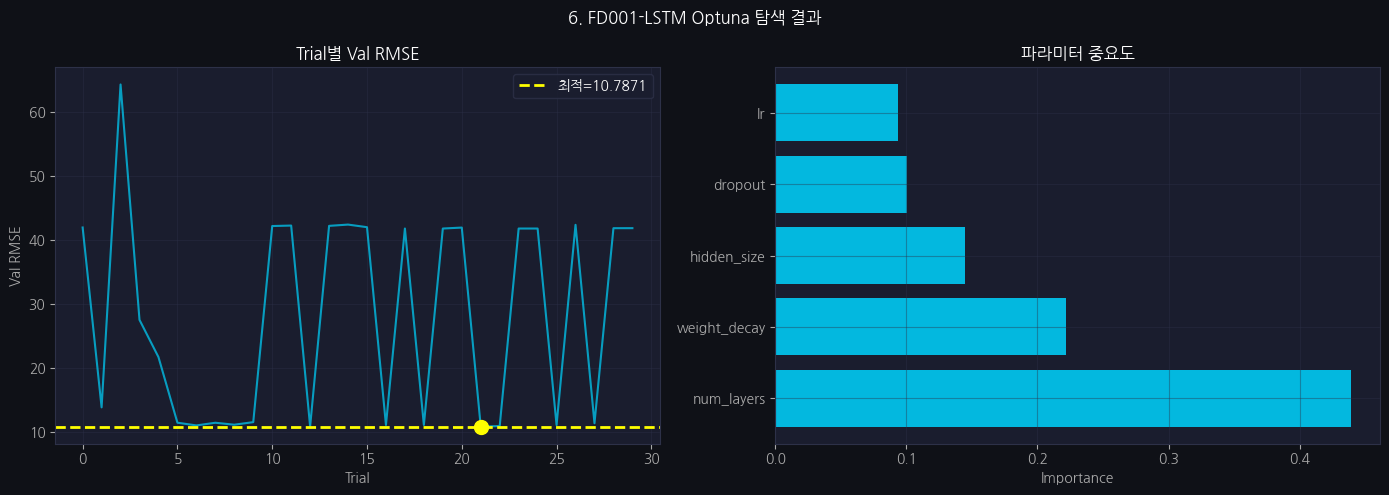

In [10]:
print(f'=== 6. Optuna HPO — {MODEL_NAME_STR} ({N_TRIALS} trials) ===')

def objective(trial):
    params = {
        'hidden_size' : trial.suggest_int('hidden_size', 32, 256),
        'num_layers'  : trial.suggest_int('num_layers',  1,  3),
        'dropout'     : trial.suggest_float('dropout',   0.1, 0.5),
        'lr'          : trial.suggest_float('lr',        1e-4, 1e-2, log=True),
    }
    if USE_ADAMW:
        params['weight_decay'] = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    model = train_model(params, EPOCHS_SEARCH)
    # 전체 validation RMSE 기준 (논문 표준 방식)
    val_rmse_full, _, _, _ = evaluate_loader(model, val_loader)
    # 메모리 정리
    del model
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return val_rmse_full

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    study_name=f'{DATASET_NAME}_{MODEL_NAME_STR}'
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'\n✅ Optuna 완료')
print(f'   최적 파라미터: {best_params}')
print(f'   최적 Val RMSE: {study.best_value:.4f}')

# 탐색 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'6. {DATASET_NAME}-{MODEL_NAME_STR} Optuna 탐색 결과', fontweight='bold')

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], color=MODEL_COLOR, lw=1.5, alpha=0.7)
axes[0].axhline(study.best_value, color='yellow', ls='--', lw=2, label=f'최적={study.best_value:.4f}')
axes[0].scatter([study.best_trial.number],[study.best_value], color='yellow', s=100, zorder=5)
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Val RMSE'); axes[0].legend()
axes[0].set_title('Trial별 Val RMSE')

# 파라미터 중요도
try:
    importance = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importance.keys()), list(importance.values()), color=MODEL_COLOR, alpha=0.85)
    axes[1].set_title('파라미터 중요도'); axes[1].set_xlabel('Importance')
except Exception as e:
    axes[1].text(0.3, 0.5, f'중요도 계산 불가\n{e}', transform=axes[1].transAxes)
plt.tight_layout(); plt.show()


## 7. 최적 파라미터로 최종 학습

In [11]:
print(f'=== 7. 최종 학습 (epochs={EPOCHS_FINAL}) ===')
print(f'   파라미터: {best_params}')

mlflow.set_experiment(EXPERIMENT_NAME)

t0 = time.time()
with mlflow.start_run(run_name=f'{DATASET_NAME}_{MODEL_NAME_STR}_final'):
    BEST_MODEL = train_model(best_params, EPOCHS_FINAL)
    fit_time   = time.time() - t0
    n_params   = sum(p.numel() for p in BEST_MODEL.parameters())

    # 평가
    val_nasa_eval, val_rmse_eval = evaluate_val_eval(BEST_MODEL)
    test_rmse, test_nasa, test_preds, test_targets = evaluate_loader(BEST_MODEL, test_loader)
    test_preds = clip_rul(test_preds)

    val_rmse_full, val_ns_full, _, _ = evaluate_loader(BEST_MODEL, val_loader)

    # MLflow 기록
    mlflow.log_params({
        **best_params,
        'model'           : MODEL_NAME_STR,
        'dataset'         : DATASET_NAME,
        'optimizer'       : OPTIMIZER_NAME,
        'weight_decay'    : best_params.get('weight_decay', 'N/A'),
        'scheduler'       : 'ReduceLROnPlateau' if USE_ADAMW else 'None',
        'window_size'     : WINDOW_SIZE,
        'n_features'      : N_FEATURES,
        'n_trials'        : N_TRIALS,
        'epochs_final'    : EPOCHS_FINAL,
        'n_params'        : n_params,
    })
    mlflow.log_metrics({
        'val_nasa_eval'   : val_nasa_eval,
        'val_rmse_eval'   : val_rmse_eval,
        'val_rmse_full'   : val_rmse_full,
        'test_rmse'       : test_rmse,
        'test_nasa'       : test_nasa,
        'test_mae'        : mean_absolute_error(test_targets, test_preds),
        'test_r2'         : r2_score(test_targets, test_preds),
        'fit_seconds'     : fit_time,
    })
    mlflow.pytorch.log_model(BEST_MODEL, MODEL_NAME_STR)

print(f'\n✅ 최종 학습 완료 ({fit_time:.1f}초)')
print(f'   파라미터 수     : {n_params:,}')
print(f'   Val NASA(eval)  : {val_nasa_eval:.2f}')
print(f'   Val RMSE(eval)  : {val_rmse_eval:.3f}')
print(f'   Test RMSE       : {test_rmse:.3f}')
print(f'   Test NASA Score : {test_nasa:.2f}')


=== 7. 최종 학습 (epochs=100) ===
   파라미터: {'hidden_size': 143, 'num_layers': 2, 'dropout': 0.15758420706624968, 'lr': 0.0027729368725238042, 'weight_decay': 0.0005609293074242926}


2026/04/28 05:52:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/28 05:52:27 INFO mlflow.store.db.utils: Updating database tables
2026/04/28 05:52:29 INFO mlflow.tracking.fluent: Experiment with name 'CMAPSS_FD001_DL_LSTM' does not exist. Creating a new experiment.


    Epoch   1 | loss=631.6451 | val_rmse=68.111 | lr=2.77e-03
    Epoch  10 | loss=320.6080 | val_rmse=42.323 | lr=1.39e-03
    Epoch  20 | loss=111.4201 | val_rmse=18.707 | lr=1.39e-03
    Epoch  30 | loss=64.7321 | val_rmse=13.216 | lr=1.39e-03
    Epoch  40 | loss=58.6250 | val_rmse=11.861 | lr=1.39e-03
    Epoch  50 | loss=55.0620 | val_rmse=11.889 | lr=3.47e-04


2026/04/28 05:53:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 05:53:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


    Early stopping at epoch 54


2026/04/28 05:53:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/28 05:53:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



✅ 최종 학습 완료 (34.1초)
   파라미터 수     : 255,828
   Val NASA(eval)  : 135.09
   Val RMSE(eval)  : 16.853
   Test RMSE       : 14.959
   Test NASA Score : 412.85


## 8. 결과 시각화

=== 8. 결과 시각화 ===


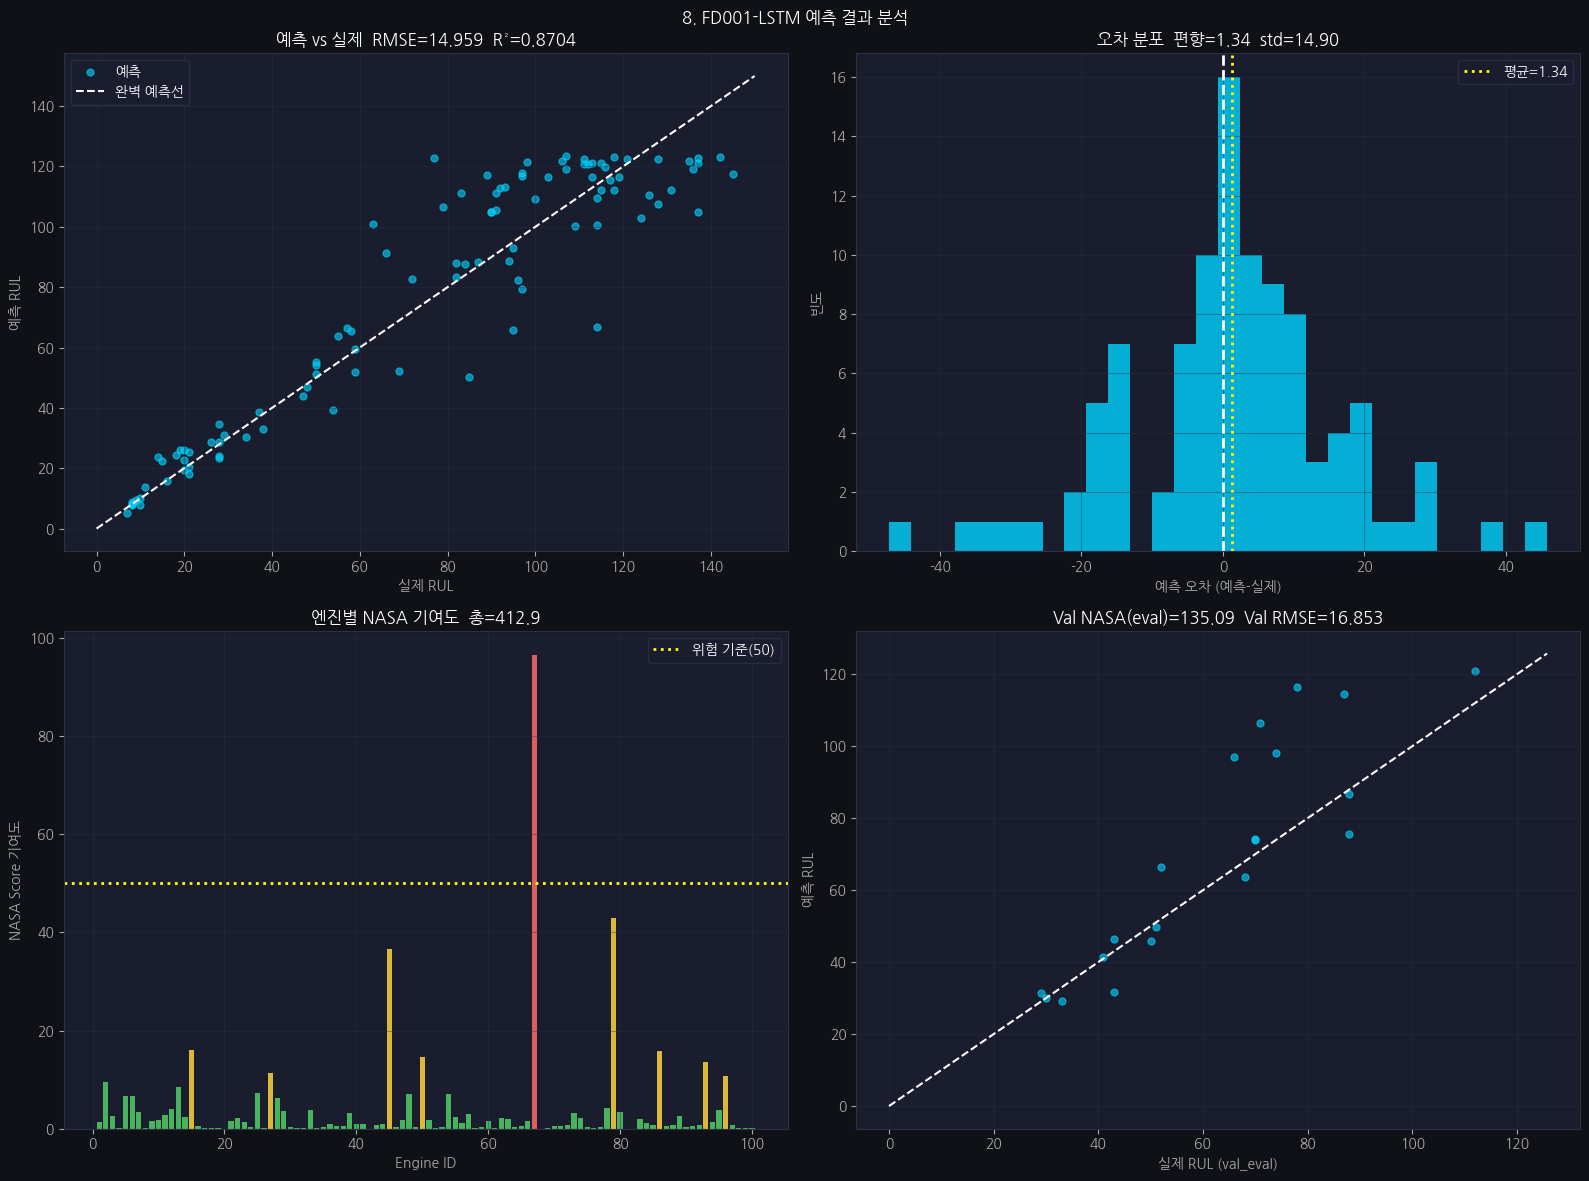

📊 결과 저장: results_dl_fd001_lstm/FD001_LSTM_result.png


In [12]:
print('=== 8. 결과 시각화 ===')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'8. {DATASET_NAME}-{MODEL_NAME_STR} 예측 결과 분석', fontweight='bold')

# 예측 vs 실제 scatter
ax = axes[0,0]
ax.scatter(test_targets, test_preds, color=MODEL_COLOR, alpha=0.6, s=25, label='예측')
lim = max(test_targets.max(), test_preds.max()) + 5
ax.plot([0,lim],[0,lim], color='white', ls='--', lw=1.5, label='완벽 예측선')
ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
ax.set_title(f'예측 vs 실제  RMSE={test_rmse:.3f}  R²={r2_score(test_targets,test_preds):.4f}')
ax.legend(); ax.set_facecolor(BG2)

# 잔차 분포
ax = axes[0,1]
errors = test_preds - test_targets
ax.hist(errors, bins=30, color=MODEL_COLOR, alpha=0.8)
ax.axvline(0, color='white', ls='--', lw=2)
ax.axvline(errors.mean(), color='yellow', ls=':', lw=2, label=f'평균={errors.mean():.2f}')
ax.set_xlabel('예측 오차 (예측-실제)'); ax.set_ylabel('빈도')
ax.set_title(f'오차 분포  편향={errors.mean():.2f}  std={errors.std():.2f}')
ax.legend(); ax.set_facecolor(BG2)

# 엔진별 NASA 기여도
ax = axes[1,0]
d = test_preds - test_targets
per_ns = np.where(d<0, np.exp(-d/13)-1, np.exp(d/10)-1)
colors_ns = ['#ff6b6b' if v>50 else ('#ffd43b' if v>10 else '#51cf66') for v in per_ns]
ax.bar(range(1,len(per_ns)+1), per_ns, color=colors_ns, alpha=0.85)
ax.axhline(50, color='yellow', ls=':', lw=2, label='위험 기준(50)')
ax.set_xlabel('Engine ID'); ax.set_ylabel('NASA Score 기여도')
ax.set_title(f'엔진별 NASA 기여도  총={test_nasa:.1f}')
ax.legend(); ax.set_facecolor(BG2)

# val_eval RUL 예측
ax = axes[1,1]
val_preds_eval = predict_np(BEST_MODEL, X_val_eval)
ax.scatter(y_val_eval, val_preds_eval, color=MODEL_COLOR, alpha=0.6, s=25, label='Val 엔진별')
lim2 = max(y_val_eval.max(), val_preds_eval.max()) + 5
ax.plot([0,lim2],[0,lim2], color='white', ls='--', lw=1.5)
ax.set_xlabel('실제 RUL (val_eval)'); ax.set_ylabel('예측 RUL')
ax.set_title(f'Val NASA(eval)={val_nasa_eval:.2f}  Val RMSE={val_rmse_eval:.3f}')
ax.set_facecolor(BG2)

plt.tight_layout()
result_plot_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_result.png')
plt.savefig(result_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 결과 저장: {result_plot_path}')


## 9. 엔진별 RUL 예측 곡선

=== 9. 엔진별 RUL 예측 곡선 ===


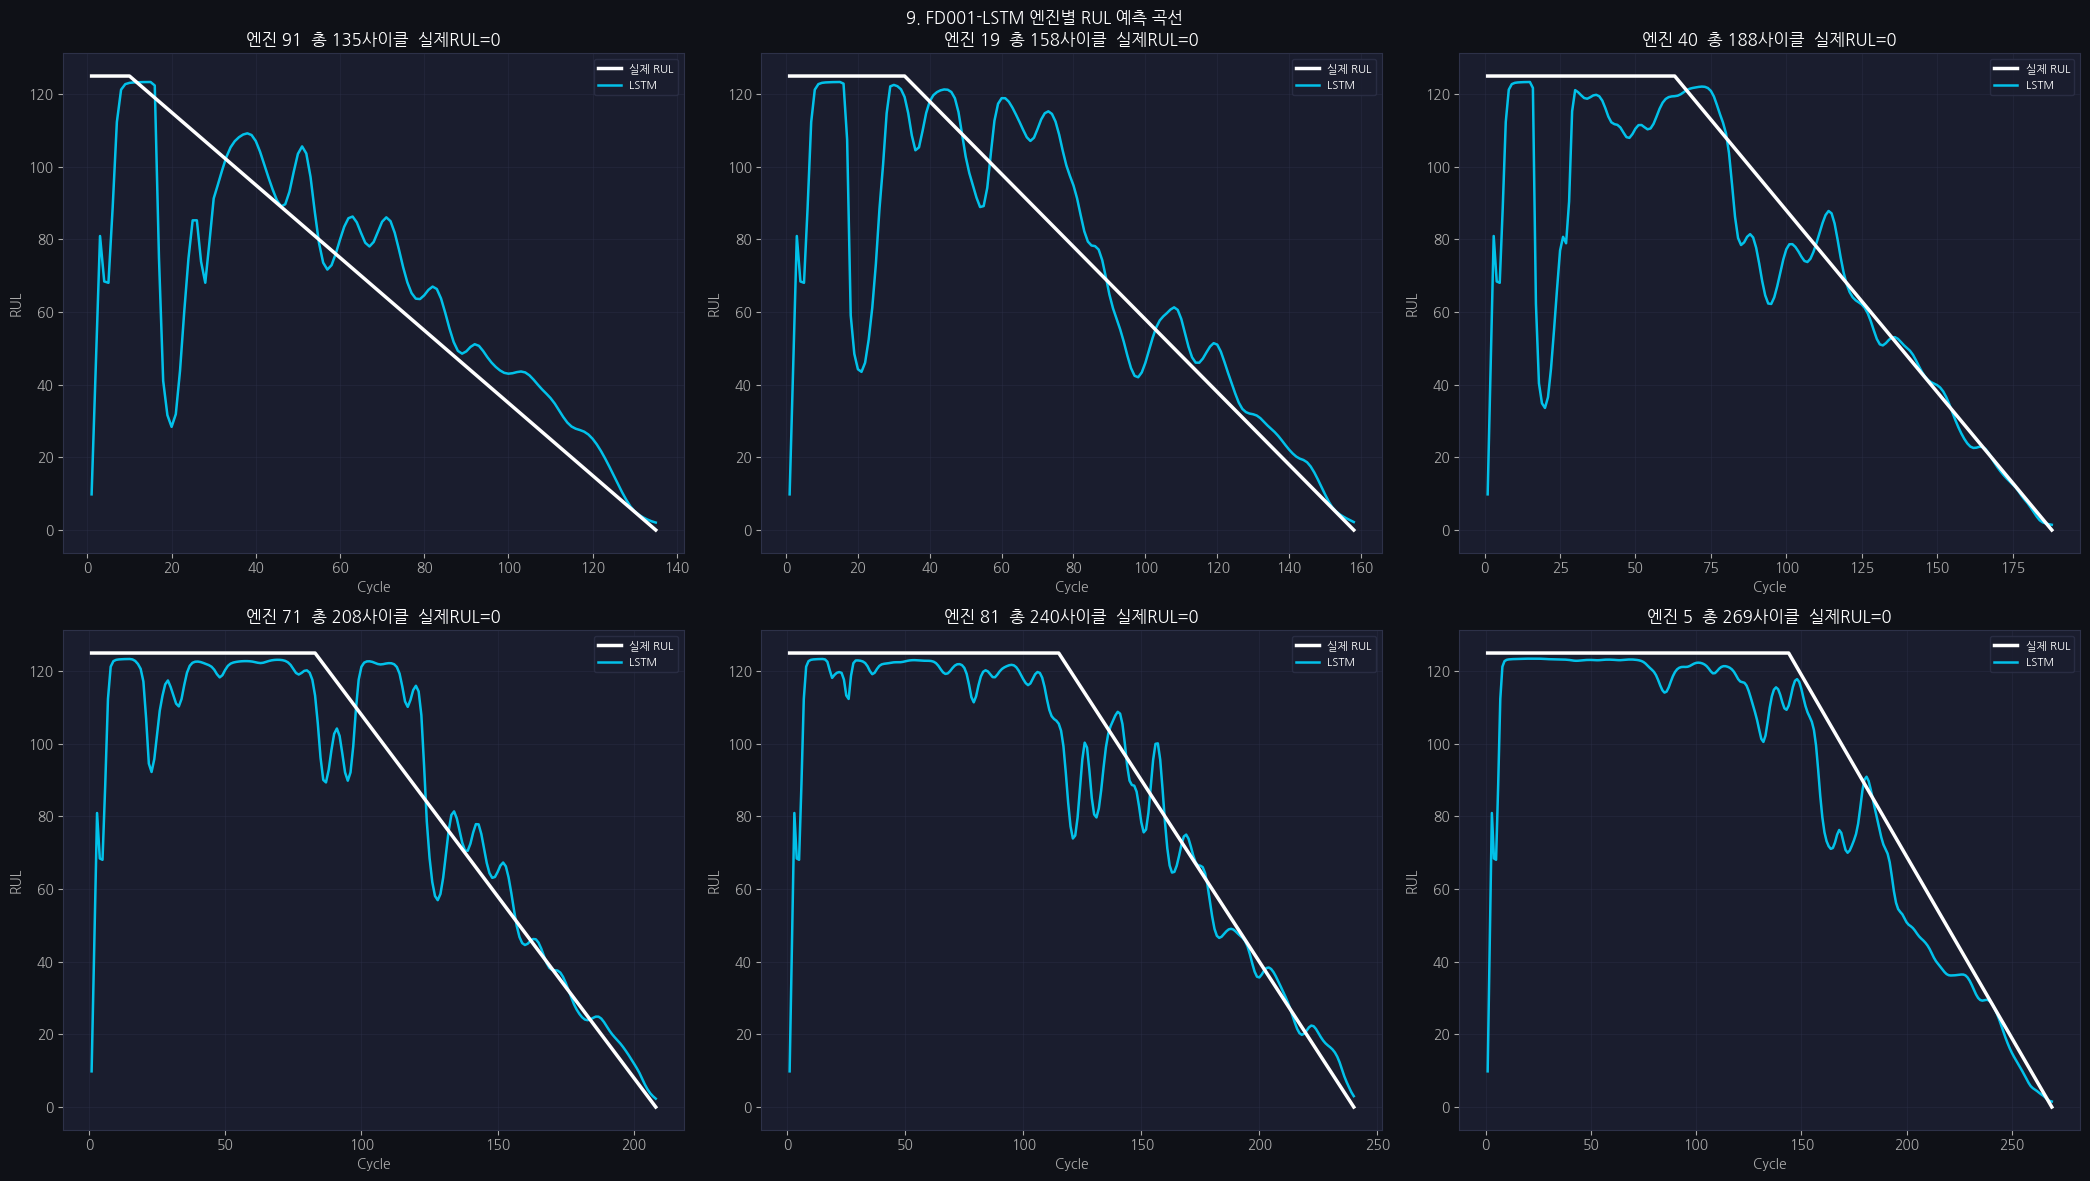

📊 RUL 곡선 저장: results_dl_fd001_lstm/FD001_LSTM_rul_curves.png


In [13]:
print('=== 9. 엔진별 RUL 예측 곡선 ===')

valid_ml_local = pd.read_csv(os.path.join(DATA_DIR, 'FD001_ml_valid.csv'))
if 'unit' in valid_ml_local.columns:
    valid_ml_local.rename(columns={'unit':'unit_nr','cycle':'time_cycles'}, inplace=True)

val_lifecycles = valid_ml_local.groupby('unit_nr')['time_cycles'].max().sort_values()
n_sel = min(6, len(val_lifecycles))
sel_units = val_lifecycles.iloc[np.linspace(0,len(val_lifecycles)-1,n_sel,dtype=int)].index.tolist()

fig, axes = plt.subplots(2,3,figsize=(21,12))
fig.suptitle(f'9. {DATASET_NAME}-{MODEL_NAME_STR} 엔진별 RUL 예측 곡선', fontweight='bold')

for ax, uid in zip(axes.flat, sel_units):
    udf  = valid_ml_local[valid_ml_local['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
    n    = len(udf)
    true_rul = udf['RUL'].values
    preds_all = []
    for t in range(n):
        start = max(0, t-WINDOW_SIZE+1)
        seg   = udf[DL_FEATURES].values[start:t+1].astype(np.float32)
        if len(seg) < WINDOW_SIZE:
            pad = np.zeros((WINDOW_SIZE-len(seg), N_FEATURES), np.float32)
            seg = np.vstack([pad, seg])
        preds_all.append(float(predict_np(BEST_MODEL, seg[np.newaxis])[0]))

    ax.plot(udf['time_cycles'], true_rul, color='white', lw=2.5, label='실제 RUL', zorder=5)
    ax.plot(udf['time_cycles'], preds_all, color=MODEL_COLOR, lw=1.8, alpha=0.9, label=MODEL_NAME_STR)
    ax.set_title(f'엔진 {uid}  총 {n}사이클  실제RUL={true_rul[-1]:.0f}')
    ax.set_xlabel('Cycle'); ax.set_ylabel('RUL')
    ax.legend(fontsize=8); ax.set_facecolor(BG2)

plt.tight_layout()
curve_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_rul_curves.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 RUL 곡선 저장: {curve_path}')


## 10. 모델 및 산출물 저장

In [14]:
print('=== 10. 모델 저장 ===')

state_path = os.path.join(MODEL_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_best.pt')
arch_path  = os.path.join(MODEL_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_arch.json')
torch.save(BEST_MODEL.state_dict(), state_path)
with open(arch_path,'w') as f:
    json.dump(best_params, f, indent=2)

result_summary = {
    'dataset'      : DATASET_NAME,
    'model'        : MODEL_NAME_STR,
    'optimizer'    : OPTIMIZER_NAME,
    'weight_decay' : best_params.get('weight_decay','N/A'),
    'scheduler'    : 'ReduceLROnPlateau' if USE_ADAMW else 'None',
    'params'       : best_params,
    'n_params'     : n_params,
    'n_trials'     : N_TRIALS,
    'val_eval_nasa': round(val_nasa_eval,2),
    'val_eval_rmse': round(val_rmse_eval,3),
    'test_rmse'    : round(test_rmse,3),
    'test_nasa'    : round(test_nasa,2),
    'test_mae'     : round(mean_absolute_error(test_targets, test_preds),3),
    'test_r2'      : round(r2_score(test_targets, test_preds),4),
    'fit_seconds'  : round(fit_time,1),
}
summary_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_summary.json')
with open(summary_path,'w',encoding='utf-8') as f:
    json.dump(result_summary, f, ensure_ascii=False, indent=2)

# 예측 결과 CSV
pred_csv_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_test_pred.csv')
pd.DataFrame({
    'engine_id'    : range(1, len(test_targets)+1),
    'actual_rul'   : test_targets.astype(int),
    'predicted_rul': test_preds.round(2),
    'error'        : (test_preds - test_targets).round(2),
}).to_csv(pred_csv_path, index=False, encoding='utf-8-sig')

print(f'  모델 저장: {state_path}')
print(f'  요약 저장: {summary_path}')
print(f'  예측 CSV : {pred_csv_path}')


=== 10. 모델 저장 ===
  모델 저장: models_dl_fd001_lstm/FD001_LSTM_best.pt
  요약 저장: results_dl_fd001_lstm/FD001_LSTM_summary.json
  예측 CSV : results_dl_fd001_lstm/FD001_LSTM_test_pred.csv


## 11. 구글 드라이브 자동 저장

In [15]:
print('=== 11. 구글 드라이브 저장 ===')
import json as _json

BEST_DIR = '/content/drive/MyDrive/sparta_project/best_results'
os.makedirs(BEST_DIR, exist_ok=True)

# 예측 CSV 저장
drive_pred_path = os.path.join(BEST_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_pred.csv')

# 이전 최고 성능 비교 후 저장
meta_path = os.path.join(BEST_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_best.json')
if os.path.exists(meta_path):
    with open(meta_path) as f:
        prev = _json.load(f)
    prev_rmse = prev.get('test_rmse', float('inf'))
else:
    prev_rmse = float('inf')

if test_rmse < prev_rmse:
    pd.DataFrame({
        'engine_id'    : range(1, len(test_targets)+1),
        'actual_rul'   : test_targets.astype(int),
        'predicted_rul': test_preds.round(2),
    }).to_csv(drive_pred_path, index=False, encoding='utf-8-sig')

    with open(meta_path,'w') as f:
        _json.dump({
            'dataset'      : DATASET_NAME,
            'model'        : MODEL_NAME_STR,
            'optimizer'    : OPTIMIZER_NAME,
            'test_rmse'    : round(test_rmse,4),
            'test_nasa'    : round(test_nasa,2),
            'val_eval_nasa': round(val_nasa_eval,2),
            'params'       : best_params,
        }, f, ensure_ascii=False, indent=2)

    print(f'🏆 최고 성능 갱신! RMSE={test_rmse:.4f} → 드라이브 저장 완료')
    print(f'   저장 위치: {drive_pred_path}')
else:
    print(f'📊 현재 RMSE={test_rmse:.4f} | 기존 최고={prev_rmse:.4f} → 저장 안함')


=== 11. 구글 드라이브 저장 ===
🏆 최고 성능 갱신! RMSE=14.9590 → 드라이브 저장 완료
   저장 위치: /content/drive/MyDrive/sparta_project/best_results/FD001_LSTM_pred.csv


## 12. 최종 요약

In [16]:
print('='*70)
print(f' {DATASET_NAME}-{MODEL_NAME_STR} 실험 최종 요약')
print('='*70)
print(f'\n[실험 설정]')
print(f'  데이터셋  : {DATASET_NAME} (HPC 열화 (단일 조건))')
print(f'  모델      : {MODEL_NAME_STR} (단방향 LSTM — 순방향 시계열 패턴 학습)')
print(f'  옵티마이저: {OPTIMIZER_NAME}')
print(f'  Scheduler : {"ReduceLROnPlateau" if USE_ADAMW else "없음"}')
print(f'  N_TRIALS  : {N_TRIALS}')
print(f'  파라미터 수: {n_params:,}')
print(f'\n[최적 하이퍼파라미터]')
for k,v in best_params.items():
    print(f'  {k:20s}: {v}')
print(f'\n[성능 결과]')
print(f'  Val NASA(eval) : {val_nasa_eval:.2f}')
print(f'  Val RMSE(eval) : {val_rmse_eval:.3f}')
print(f'  Test RMSE      : {test_rmse:.3f}')
print(f'  Test NASA Score: {test_nasa:.2f}')
print(f'  Test MAE       : {mean_absolute_error(test_targets,test_preds):.3f}')
print(f'  Test R²        : {r2_score(test_targets,test_preds):.4f}')
print(f'  학습 시간      : {fit_time:.1f}초')
print(f'\n[저장 파일]')
print(f'  모델   : {state_path}')
print(f'  요약   : {summary_path}')
print(f'  예측CSV: {pred_csv_path}')
print(f'  드라이브: {BEST_DIR}/{DATASET_NAME}_{MODEL_NAME_STR}_pred.csv')
print('='*70)


 FD001-LSTM 실험 최종 요약

[실험 설정]
  데이터셋  : FD001 (HPC 열화 (단일 조건))
  모델      : LSTM (단방향 LSTM — 순방향 시계열 패턴 학습)
  옵티마이저: AdamW
  Scheduler : ReduceLROnPlateau
  N_TRIALS  : 30
  파라미터 수: 255,828

[최적 하이퍼파라미터]
  hidden_size         : 143
  num_layers          : 2
  dropout             : 0.15758420706624968
  lr                  : 0.0027729368725238042
  weight_decay        : 0.0005609293074242926

[성능 결과]
  Val NASA(eval) : 135.09
  Val RMSE(eval) : 16.853
  Test RMSE      : 14.959
  Test NASA Score: 412.85
  Test MAE       : 10.882
  Test R²        : 0.8704
  학습 시간      : 34.1초

[저장 파일]
  모델   : models_dl_fd001_lstm/FD001_LSTM_best.pt
  요약   : results_dl_fd001_lstm/FD001_LSTM_summary.json
  예측CSV: results_dl_fd001_lstm/FD001_LSTM_test_pred.csv
  드라이브: /content/drive/MyDrive/sparta_project/best_results/FD001_LSTM_pred.csv
